# Diabetes Random Forest 회귀

## 개요
- Random Forest Regressor를 활용한 당뇨병 진행도 예측
- GridSearchCV로 하이퍼파라미터 최적화
- 피처 중요도 분석

## Random Forest 특징 (회귀)
- 비선형 관계 학습 가능
- 이상치에 강건함
- 스케일링 불필요
- 피처 중요도 자동 산출

## 주요 단계
1. 데이터 로드 및 분리
2. GridSearchCV 하이퍼파라미터 탐색
3. 회귀 성능 평가 (RMSE, R2)
4. 피처 중요도 분석

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

## 1. 데이터 로드

**Diabetes 데이터셋**
- 442개 샘플, 10개 피처
- 당뇨병 진행도 예측 (회귀 문제)
- 타겟: 1년 후 질병 진행 정도

In [2]:
# 데이터 로드
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(diabetes.feature_names)}")
print(f"\n타겟 통계:")
print(f"  평균: {y.mean():.2f}")
print(f"  범위: {y.min():.0f} ~ {y.max():.0f}")

데이터 크기: (442, 10)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

타겟 통계:
  평균: 152.13
  범위: 25 ~ 346


**데이터 샘플 확인**

In [3]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

기술 통계:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072

**학습/테스트 데이터 분리**

In [4]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 타겟 통계:")
print(f"  평균: {y_train.mean():.2f}")
print(f"  표준편차: {y_train.std():.2f}")

Train: (353, 10), Test: (89, 10)

Train 타겟 통계:
  평균: 153.74
  표준편차: 77.95


## 2. Random Forest Regressor

**Random Forest 회귀 특징**
- 비선형 관계 학습: 복잡한 패턴 포착
- 이상치 강건성: 평균으로 예측하므로 이상치 영향 적음
- 과적합 방지: 앙상블 효과
- 스케일링 불필요: 트리 기반

**하이퍼파라미터**
- n_estimators: 트리 개수
- max_depth: 트리 최대 깊이
- min_samples_split: 노드 분할 최소 샘플
- max_features: 각 분할에서 고려할 피처 수

**모델 및 하이퍼파라미터 그리드 설정**

In [5]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)

# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2', None]
}

print("Random Forest Regressor 생성")
print(f"\n파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

Random Forest Regressor 생성

파라미터 그리드:
  n_estimators: [100, 200]
  max_depth: [5, 10, None]
  min_samples_split: [2, 5]
  max_features: ['sqrt', 'log2', None]

총 조합 수: 36개


## 3. GridSearchCV 하이퍼파라미터 탐색

**GridSearchCV 설정**
- cv: KFold(5) - 회귀 문제는 KFold 사용
- scoring: r2 - R2 Score 최대화
- n_jobs=-1: 모든 CPU 코어 사용

In [6]:
# GridSearchCV
print("Tuning RandomForest Regressor...")
print("(교차검증 수행 중...)\n")

grid_reg = GridSearchCV(
    rf_reg,
    param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train, y_train)
print("\nGridSearchCV 완료!")

Tuning RandomForest Regressor...
(교차검증 수행 중...)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [7]:
# 최적 모델 추출
best_reg = grid_reg.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {grid_reg.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_reg.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best R2 Score (Train CV): 0.4455

Best Parameters:
  max_depth: 5
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 200


**GridSearchCV 상위 결과**

In [8]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_reg.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_max_features',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators param_max_depth  param_min_samples_split param_max_features  mean_test_score  std_test_score
                200               5                        5               sqrt         0.445454        0.023906
                200               5                        5               log2         0.445454        0.023906
                100               5                        5               sqrt         0.445246        0.025432
                100               5                        5               log2         0.445246        0.025432
                100               5                        2               sqrt         0.441715        0.024185


## 5. 테스트 데이터 평가

**회귀 성능 평가**
- RMSE: 예측 오차 크기
- R2 Score: 설명력 (1에 가까울수록 좋음)

In [9]:
# 테스트 데이터 예측
y_pred = best_reg.predict(X_test)

# 평가 지표
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))

print("\n[테스트 성능]")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")


[테스트 성능]
Test RMSE: 53.1681
Test R2 Score: 0.4664
Test MAE: 43.5293


**예측 결과 시각화**

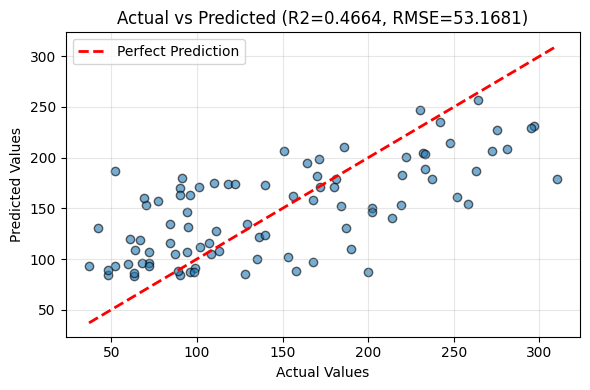

In [16]:
# 실제값 vs 예측값
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted (R2={r2:.4f}, RMSE={rmse:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**Gini Importance (회귀)**
- 각 피처가 MSE를 얼마나 감소시키는지 측정
- 값이 클수록 타겟 예측에 중요
- 당뇨병 진행도에 영향을 미치는 주요 요인 파악

In [12]:
# 피처 중요도 추출
importances = best_reg.feature_importances_
feature_names = diabetes.feature_names
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': np.array(feature_names)[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
Feature  Importance
    bmi    0.283119
     s5    0.244414
     bp    0.116631
     s3    0.078956
     s6    0.075779
     s4    0.072196
     s1    0.044994
     s2    0.043362
    age    0.032694
    sex    0.007855


**피처 중요도 시각화**

/tmp/ipython-input-356762836.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')


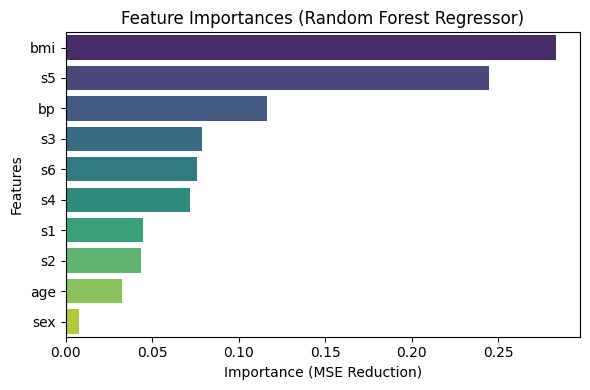

In [17]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette='viridis')
plt.title("Feature Importances (Random Forest Regressor)")
plt.xlabel("Importance (MSE Reduction)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 7. 상위 피처만 사용한 모델 비교

**상위 5개 피처로 재학습**

In [14]:
# 상위 5개 피처 선택
top_5_features = np.array(feature_names)[indices[:5]]
print(f"상위 5개 피처: {list(top_5_features)}")

# 상위 피처만으로 학습
X_train_top5 = X_train[top_5_features]
X_test_top5 = X_test[top_5_features]

rf_top5 = RandomForestRegressor(**grid_reg.best_params_, random_state=42)
rf_top5.fit(X_train_top5, y_train)
y_pred_top5 = rf_top5.predict(X_test_top5)

rmse_top5 = np.sqrt(mean_squared_error(y_test, y_pred_top5))
r2_top5 = r2_score(y_test, y_pred_top5)

# 비교
print("\n성능 비교:")
print(f"모든 피처 (10개):")
print(f"  RMSE = {rmse:.4f}, R2 = {r2:.4f}")
print(f"\n상위 5개 피처:")
print(f"  RMSE = {rmse_top5:.4f}, R2 = {r2_top5:.4f}")
print(f"\nRMSE 차이: {rmse_top5 - rmse:+.4f}")
print(f"R2 차이: {r2_top5 - r2:+.4f}")

상위 5개 피처: [np.str_('bmi'), np.str_('s5'), np.str_('bp'), np.str_('s3'), np.str_('s6')]

성능 비교:
모든 피처 (10개):
  RMSE = 53.1681, R2 = 0.4664

상위 5개 피처:
  RMSE = 52.6013, R2 = 0.4778

RMSE 차이: -0.5668
R2 차이: +0.0113


## 8. 기본 파라미터 vs 최적 파라미터 비교

**GridSearch 효과 검증**

In [15]:
# 기본 파라미터로 학습
rf_default = RandomForestRegressor(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
r2_default = r2_score(y_test, y_pred_default)

# 비교
print("\nGridSearch 효과:")
print(f"기본 파라미터:")
print(f"  RMSE = {rmse_default:.4f}, R2 = {r2_default:.4f}")
print(f"\n최적 파라미터:")
print(f"  RMSE = {rmse:.4f}, R2 = {r2:.4f}")
print(f"\nRMSE 개선: {rmse_default - rmse:+.4f}")
print(f"R2 개선: {r2 - r2_default:+.4f}")


GridSearch 효과:
기본 파라미터:
  RMSE = 54.3324, R2 = 0.4428

최적 파라미터:
  RMSE = 53.1681, R2 = 0.4664

RMSE 개선: +1.1643
R2 개선: +0.0236
